In [1]:
import pandas as pd

df = pd.read_csv('dataset.csv')

df.head()

,City,Latitude,Longitude,Sales
0,Chennai,13.0827,80.2707,5000
1,Bangalore,12.9716,77.5946,7000
2,Hyderabad,17.3850,78.4867,6500
3,Mumbai,19.0760,72.8777,9000
4,Delhi,28.7041,77.1025,8500


In [2]:
!pip install folium

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import folium

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   City       5 non-null      object 
 1   Latitude   5 non-null      float64
 2   Longitude  5 non-null      float64
 3   Sales      5 non-null      int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 292.0+ bytes
None


In [5]:
print(df.describe())

        Latitude  Longitude        Sales
count   5.000000   5.000000     5.000000
mean   18.243880  77.266440  7200.000000
std     6.428083   2.734512  1604.680654
min    12.971600  72.877700  5000.000000
25%    13.082700  77.102500  6500.000000
50%    17.385000  77.594600  7000.000000
75%    19.076000  78.486700  8500.000000
max    28.704100  80.270700  9000.000000


In [7]:
print(df.columns)

Index(['City ', 'Latitude', 'Longitude', 'Sales'], dtype='object')


In [8]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['City', 'Latitude', 'Longitude', 'Sales'], dtype='object')


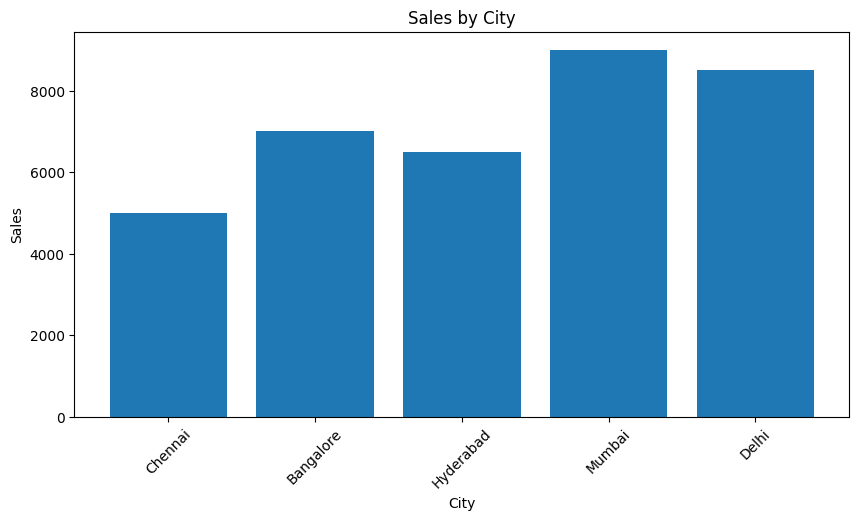

In [9]:
plt.figure(figsize=(10,5))

plt.bar(df['City'], df['Sales'])

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [10]:
m = folium.Map(
    location=[20.5937,78.9629],
    zoom_start=5
)

m

In [11]:
for index,row in df.iterrows():

    folium.Marker(
        [row['Latitude'],row['Longitude']],
        popup=f"{row['City']} - Sales:{row['Sales']}"
    ).add_to(m)

m

In [12]:
m.save("sales_map.html")

In [13]:
df.sort_values(
    by='Sales',
    ascending=False
)

,City,Latitude,Longitude,Sales
3,Mumbai,19.0760,72.8777,9000
4,Delhi,28.7041,77.1025,8500
1,Bangalore,12.9716,77.5946,7000
2,Hyderabad,17.3850,78.4867,6500
0,Chennai,13.0827,80.2707,5000


In [14]:
avg = df['Sales'].mean()

print("Average Sales =", avg)

Average Sales = 7200.0


In [15]:
high_demand = df[
    df['Sales'] > avg
]

high_demand

,City,Latitude,Longitude,Sales
3,Mumbai,19.0760,72.8777,9000
4,Delhi,28.7041,77.1025,8500


In [16]:
print("Recommended Areas For Business Expansion")

print(high_demand[['City','Sales']])

Recommended Areas For Business Expansion
     City  Sales
3  Mumbai   9000
4   Delhi   8500


In [17]:
print("""
Conclusion

The sales data was analyzed using geospatial techniques.

Cities with the highest demand:
1. Mumbai
2. Delhi
3. Bangalore

These regions are suitable for future business expansion because of their higher sales performance.
""")


Conclusion

The sales data was analyzed using geospatial techniques.

Cities with the highest demand:
1. Mumbai
2. Delhi
3. Bangalore

These regions are suitable for future business expansion because of their higher sales performance.

